# Week 1 — Dataset Exploration
**Goal:** Load and explore the two datasets central to this project:
- **WNC** (Wiki Neutrality Corpus) — training data for the T5 neutralizer
- **AllSides** (`liyucheng/allsides`) — evaluation data for the downstream experiment

By the end of this notebook you should have confirmed both datasets load cleanly, understand their label/length distributions, and have everything saved to Drive for use in Week 2.

---
## 0. Environment Setup — Mount Drive & Clone Repo

In [1]:
# ── Step 1: Mount Google Drive ──────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')
print("✅ Drive mounted at /content/drive/MyDrive/")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive mounted at /content/drive/MyDrive/


In [2]:
# ── Step 2: Clone / pull the project repo ───────────────────────────────────
import os

REPO_URL  = "https://github.com/paradox1065/political-bias-neutralization-summarization.git"
REPO_NAME = "political-bias-neutralization-summarization"

if not os.path.exists(f"/content/{REPO_NAME}"):
    !git clone {REPO_URL}
else:
    %cd /content/{REPO_NAME}
    !git pull
    %cd /content

print(f"✅ Repo ready at /content/{REPO_NAME}")

/content/political-bias-neutralization-summarization
Already up to date.
/content
✅ Repo ready at /content/political-bias-neutralization-summarization


In [3]:
# ── Step 3: Set working directory and link outputs to Drive ──────────────────
import shutil

%cd /content/{REPO_NAME}

DRIVE_DIR = f"/content/drive/MyDrive/{REPO_NAME}"
os.makedirs(DRIVE_DIR, exist_ok=True)
os.makedirs("outputs", exist_ok=True)   # local outputs/ inside repo

print(f"Working directory : {os.getcwd()}")
print(f"Drive backup dir  : {DRIVE_DIR}")

/content/political-bias-neutralization-summarization
Working directory : /content/political-bias-neutralization-summarization
Drive backup dir  : /content/drive/MyDrive/political-bias-neutralization-summarization


In [4]:
# ── Install dependencies ─────────────────────────────────────────────────────
!pip install datasets transformers matplotlib seaborn pandas --quiet
print("✅ Dependencies installed")

✅ Dependencies installed


---
## 1. Imports

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from datasets import load_dataset
from collections import Counter

sns.set_theme(style="whitegrid", palette="muted")
SEED = 42
print("✅ Imports complete")

✅ Imports complete


---
## 2. WNC — Wiki Neutrality Corpus (Training Data)

WNC contains human-edited Wikipedia sentence pairs where editors neutralised biased phrasing. Each row is a `(biased, neutral)` pair — exactly what we need to fine-tune T5 in Week 3.

In [8]:
import json
from google.colab import files
import shutil, os

kaggle_creds_path = f"{DRIVE_DIR}/kaggle.json"   # put your kaggle.json here once

os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)

# Ensure the source file exists in Google Drive first
if not os.path.exists(kaggle_creds_path):
    print(f"⚠️  Error: kaggle.json not found in Drive at {kaggle_creds_path}")
    print("Please upload your kaggle.json to this exact path in your Google Drive.")
else:
    # Copy from Drive to the expected Kaggle config location
    shutil.copy(kaggle_creds_path, os.path.expanduser("~/.kaggle/kaggle.json"))
    os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)

    # Verify the copied file's content for debugging AND set env vars
    copied_kaggle_json_path = os.path.expanduser("~/.kaggle/kaggle.json")
    if os.path.exists(copied_kaggle_json_path):
        with open(copied_kaggle_json_path, 'r') as f:
            creds = json.load(f)
            print(f"Content of copied kaggle.json: {json.dumps(creds)}")

            # Set environment variables for Kaggle authentication
            os.environ['KAGGLE_USERNAME'] = creds.get('userName', '')
            os.environ['KAGGLE_KEY'] = creds.get('apiToken', '')
            print("✅ KAGGLE_USERNAME and KAGGLE_KEY environment variables set.")

    else:
        print("⚠️  Error: kaggle.json was not copied to ~/.kaggle/kaggle.json")

!pip install kaggle --quiet
print("✅ Kaggle credentials configured")

Content of copied kaggle.json: {"userName": "kavyat1102", "apiToken": "KGAT_099b911ee9f9ca929aff1c772e9b4d5c"}
✅ KAGGLE_USERNAME and KAGGLE_KEY environment variables set.
✅ Kaggle credentials configured


In [13]:
# ── Download WNC from Kaggle and load ───────────────────────────────────────
# Find the exact dataset slug on the Kaggle page URL:
# kaggle.com/datasets/<owner>/<dataset-name>  →  use "<owner>/<dataset-name>" below
WNC_SLUG = "chandiragunatilleke/wiki-neutrality-corpus"

!kaggle datasets download -d {WNC_SLUG} -p /content/wnc_data --unzip
print("✅ WNC downloaded")

# Inspect what files were extracted
import os
wnc_files = os.listdir("/content/wnc_data")
print("Files:", wnc_files)

Dataset URL: https://www.kaggle.com/datasets/chandiragunatilleke/wiki-neutrality-corpus
License(s): other
100% 107M/107M [00:01<00:00, 96.6MB/s]

✅ WNC downloaded
Files: ['WNC']


In [51]:
# ── Load WNC into a DataFrame ────────────────────────────────────────────────
import pandas as pd

# WNC typically ships as a .tsv with columns: rev_id, src_tok, tgt_tok (and others)
# Adjust the filename below to whichever .tsv / .csv file appeared in the output above
WNC_FILE = "/content/wnc_data/WNC/WNC/biased.word.train"   # ← adjust if needed

wnc_train_df = pd.read_csv(
    WNC_FILE,
    sep="\t",
    header=None,
    on_bad_lines="skip",
)

wnc_train_df = wnc_train_df.rename(columns={0: "rev_id", 3: "biased", 4: "neutral"})
wnc_train_df = wnc_train_df[["rev_id", "biased", "neutral"]].dropna()

print(f"✅ WNC loaded — {len(wnc_train_df):,} pairs")
wnc_train_df.head(3)

✅ WNC loaded — 53,803 pairs


,rev_id,biased,neutral
0,165188319,"chloroform ""the molecular lifesaver"" an articl...","chloroform ""the molecular lifesaver"" an articl..."
1,123204846,the free software gnu classpath project is onl...,the free software gnu classpath project is par...
2,706783956,"other campaigners, especially the controversia...","other campaigners, especially the british acti..."


In [52]:
# ── Standardise column names for downstream use ──────────────────────────────
# WNC columns vary by version; map whichever names are present to 'biased'/'neutral'
col_map = {}
for col in wnc_train_df.columns:
    lc = col.lower()
    if "pre" in lc or "biased" in lc or "src" in lc or "input" in lc:
        col_map[col] = "biased"
    elif "post" in lc or "neutral" in lc or "tgt" in lc or "output" in lc:
        col_map[col] = "neutral"

wnc_train_df = wnc_train_df.rename(columns=col_map)
print(f"Columns after renaming: {list(wnc_train_df.columns)}")

# Confirm we have both sides
assert "biased" in wnc_train_df.columns, "Could not find biased column — check column names above and adjust col_map"
assert "neutral" in wnc_train_df.columns, "Could not find neutral column — check column names above and adjust col_map"
print("✅ Biased / neutral columns confirmed")

Columns after renaming: ['rev_id', 'biased', 'neutral']
✅ Biased / neutral columns confirmed


In [53]:
# ── Compute token-level length proxies (whitespace split — fast) ─────────────
wnc_train_df["biased_len"]  = wnc_train_df["biased"].str.split().str.len()
wnc_train_df["neutral_len"] = wnc_train_df["neutral"].str.split().str.len()

print(wnc_train_df[["biased_len", "neutral_len"]].describe().round(1))

       biased_len  neutral_len
count     53803.0      53803.0
mean         26.4         26.1
std          14.5         14.5
min           2.0          1.0
25%          16.0         16.0
50%          24.0         23.0
75%          33.0         33.0
max         225.0        225.0


In [54]:
# ── Null / empty check ───────────────────────────────────────────────────────
null_counts = wnc_train_df[["biased", "neutral"]].isnull().sum()
empty_counts = (wnc_train_df[["biased", "neutral"]] == "").sum()
print("Null counts:\n", null_counts)
print("\nEmpty-string counts:\n", empty_counts)

Null counts:
 biased     0
neutral    0
dtype: int64

Empty-string counts:
 biased     0
neutral    0
dtype: int64


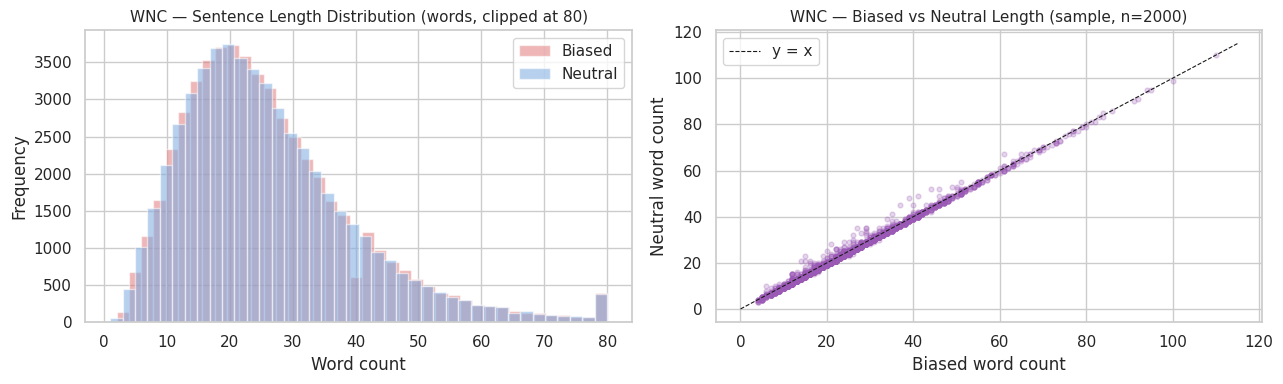

✅ WNC length plots saved


In [55]:
# ── Visualise WNC text-length distributions ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Overlapping KDE — biased vs neutral length
ax = axes[0]
wnc_train_df["biased_len"].clip(upper=80).plot.hist(
    bins=40, alpha=0.55, color="#e07b7b", label="Biased", ax=ax)
wnc_train_df["neutral_len"].clip(upper=80).plot.hist(
    bins=40, alpha=0.55, color="#7baae0", label="Neutral", ax=ax)
ax.set_title("WNC — Sentence Length Distribution (words, clipped at 80)", fontsize=11)
ax.set_xlabel("Word count")
ax.set_ylabel("Frequency")
ax.legend()

# Scatter: biased length vs neutral length (sample 2000 pts for readability)
ax2 = axes[1]
sample = wnc_train_df.sample(min(2000, len(wnc_train_df)), random_state=SEED)
ax2.scatter(sample["biased_len"], sample["neutral_len"],
            alpha=0.25, s=12, color="#9b59b6")
lim = max(sample["biased_len"].max(), sample["neutral_len"].max()) + 5
ax2.plot([0, lim], [0, lim], "k--", lw=0.8, label="y = x")
ax2.set_title("WNC — Biased vs Neutral Length (sample, n=2000)", fontsize=11)
ax2.set_xlabel("Biased word count")
ax2.set_ylabel("Neutral word count")
ax2.legend()

plt.tight_layout()
plt.savefig("outputs/wnc_length_distribution.png", dpi=150)
shutil.copy("outputs/wnc_length_distribution.png",
            f"{DRIVE_DIR}/wnc_length_distribution.png")
plt.show()
print("✅ WNC length plots saved")

In [56]:
# ── Split sizes (train / dev / test) ────────────────────────────────────────
print("WNC split sizes:")
for split_name, split_file in [("train", "biased.word.train"), ("dev", "biased.word.dev"), ("test", "biased.word.test")]:
    path = f"/content/wnc_data/WNC/WNC/{split_file}"   # adjust folder path if needed
    if os.path.exists(path):
        n = pd.read_csv(path, sep="\t", header=None, on_bad_lines="skip").shape[0]
        print(f"  {split_name:12s}: {n:>7,} rows")
    else:
        print(f"  {split_name:12s}: file not found")

WNC split sizes:
  train       :  53,803 rows
  dev         :     700 rows
  test        :   1,000 rows


---
## 3. AllSides — Political News Articles (Evaluation Data)

AllSides articles are rated **left / center / right** by human panels. We use left and right articles as our evaluation set: run both experimental conditions (direct summarisation vs neutralise-then-summarise) and compare bias scores on the resulting summaries.

In [30]:
# Load AllSides from Hugging Face Hub
# Dataset card: https://huggingface.co/datasets/liyucheng/allsides
print("Loading AllSides ...")
allsides_raw = load_dataset("liyucheng/allsides", trust_remote_code=True)
print(allsides_raw)
print("\n✅ AllSides loaded")

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'liyucheng/allsides' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'liyucheng/allsides' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Loading AllSides ...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/572 [00:00<?, ?B/s]

data/train-00000-of-00001-da1e7ddeb61904(…):   0%|          | 0.00/2.45M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/987 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['title', 'url', 'topic', 'camp', 'full_stories', 'articles', '__index_level_0__'],
        num_rows: 987
    })
})

✅ AllSides loaded


In [31]:
# ── Inspect structure ────────────────────────────────────────────────────────
allsides_df = allsides_raw["train"].to_pandas()
print(f"Total rows : {len(allsides_df):,}")
print(f"Columns    : {list(allsides_df.columns)}")
allsides_df.head(3)

Total rows : 987
Columns    : ['title', 'url', 'topic', 'camp', 'full_stories', 'articles', '__index_level_0__']


,title,url,topic,camp,full_stories,articles,__index_level_0__
0,MAGA Fans Drop Huge ‘Trump Or Death’ Banner At...,https://www.allsides.com/news/2023-09-07-1249/...,2024 Presidential Election,rights,https://dailycaller.com/2023/09/07/maga-fans-d...,,0
1,Chris Christie: I’m ‘Really Concerned’ for Tru...,https://www.allsides.com/news/2023-09-07-1246/...,2024 Presidential Election,rights,https://www.breitbart.com/clips/2023/09/06/chr...,Chris Christie: I’m ‘Really Concerned’ for Tru...,1
2,Pence: GOP Must Choose Between Conservatism An...,https://www.allsides.com/news/2023-09-06-1538/...,2024 Presidential Election,rights,https://www.dailywire.com/news/pence-gop-must-...,— NEWS —\nPence: GOP Must Choose Between Conse...,2


In [33]:
# ── Identify the ideology label column ──────────────────────────────────────
# Possible names: 'bias', 'label', 'leaning', 'category', 'rating' …
label_col = None
for col in allsides_df.columns:
    unique_vals = set(allsides_df[col].dropna().astype(str).str.lower().unique())
    # Include 'rights' as a possible unique value for detection
    if unique_vals & {"left", "right", "center", "l", "r", "c", "rights"}:
        label_col = col
        break

# Fallback: manually set if auto-detection fails or is ambiguous
if label_col is None:
    # Based on previous output, 'camp' is the most likely label column
    if 'camp' in allsides_df.columns:
        label_col = 'camp'
    else:
        # Original fallback if 'camp' is also not suitable or present
        for col in allsides_df.columns:
            print(f"{col}: {allsides_df[col].value_counts().head(5).to_dict()}")
        raise ValueError("Could not auto-detect label column. Inspect output above and set label_col manually.")

print(f"✅ Label column detected: '{label_col}'")
print(allsides_df[label_col].value_counts())

✅ Label column detected: 'camp'
camp
rights     331
lefts      328
centers    328
Name: count, dtype: int64


In [34]:
# ── Identify the article text column ────────────────────────────────────────
text_col = None
for col in allsides_df.columns:
    if allsides_df[col].dtype == object:
        avg_len = allsides_df[col].dropna().str.len().mean()
        if avg_len > 500:   # articles are long; headlines/labels are short
            text_col = col
            break

if text_col is None:
    print("Column average lengths:")
    for col in allsides_df.select_dtypes("object").columns:
        print(f"  {col}: avg char len = {allsides_df[col].dropna().str.len().mean():.0f}")
    raise ValueError("Could not auto-detect text column. Set text_col manually based on output above.")

print(f"✅ Text column detected: '{text_col}'")
print(f"   Average character length: {allsides_df[text_col].str.len().mean():.0f}")

✅ Text column detected: 'articles'
   Average character length: 4372


In [41]:
# ── Normalise labels to lowercase strings ───────────────────────────────────
allsides_df["ideology"] = allsides_df[label_col].astype(str).str.strip().str.lower()

# Unify any variant spellings
remap = {
    "lefts"         : "left",
    "rights"        : "right",
    "centers"       : "center",
    "left-center"   : "center",
    "right-center"  : "center",
    "lean left"     : "left",
    "lean right"    : "right",
    "l"             : "left",
    "r"             : "right",
    "c"             : "center",
}
allsides_df["ideology"] = allsides_df["ideology"].replace(remap)
print("Normalised label counts:")
print(allsides_df["ideology"].value_counts())

Normalised label counts:
ideology
right     331
left      328
center    328
Name: count, dtype: int64


In [36]:
# ── Add word-count column ────────────────────────────────────────────────────
allsides_df["word_count"] = allsides_df[text_col].str.split().str.len()
print(allsides_df.groupby("ideology")["word_count"].describe().round(1))

          count    mean     std  min    25%    50%     75%      max
ideology                                                           
centers   328.0   548.3  1165.3  0.0    1.0  121.0   727.8  13056.0
lefts     328.0  1059.6   989.9  0.0  448.2  909.0  1402.0   6095.0
rights    331.0   521.0   562.3  0.0   12.0  519.0   786.5   6664.0


In [37]:
# ── Null / empty check ───────────────────────────────────────────────────────
print("Null counts:")
print(allsides_df[[text_col, "ideology"]].isnull().sum())
print("\nEmpty string counts:")
print((allsides_df[[text_col, "ideology"]] == "").sum())

Null counts:
articles    0
ideology    0
dtype: int64

Empty string counts:
articles    43
ideology     0
dtype: int64


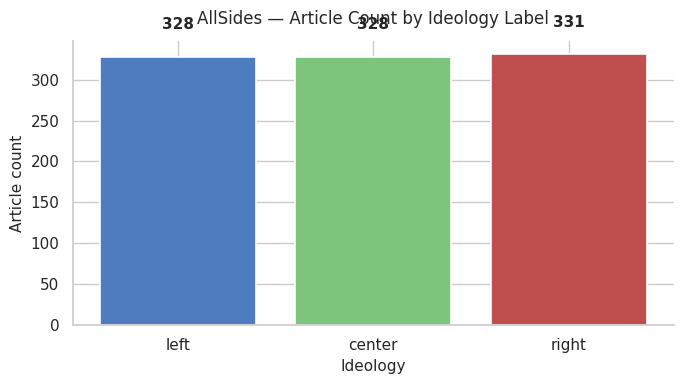

✅ Label distribution plot saved


In [42]:
# ── Figure 1: Label distribution ─────────────────────────────────────────────
label_order  = ["left", "center", "right"]
label_colors = {"left": "#4e7dbf", "center": "#7dc47d", "right": "#bf4e4e"}

counts = allsides_df["ideology"].value_counts().reindex(label_order, fill_value=0)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(counts.index,
              counts.values,
              color=[label_colors[l] for l in counts.index],
              edgecolor="white", linewidth=1.2)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
            f"{val:,}", ha="center", va="bottom", fontsize=11, fontweight="bold")

ax.set_title("AllSides — Article Count by Ideology Label", fontsize=12, pad=12)
ax.set_xlabel("Ideology", fontsize=11)
ax.set_ylabel("Article count", fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
sns.despine()
plt.tight_layout()
plt.savefig("outputs/allsides_label_distribution.png", dpi=150)
shutil.copy("outputs/allsides_label_distribution.png",
            f"{DRIVE_DIR}/allsides_label_distribution.png")
plt.show()
print("✅ Label distribution plot saved")

/tmp/ipykernel_32825/382447506.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(data_by_label, labels=label_order, patch_artist=True, notch=False,


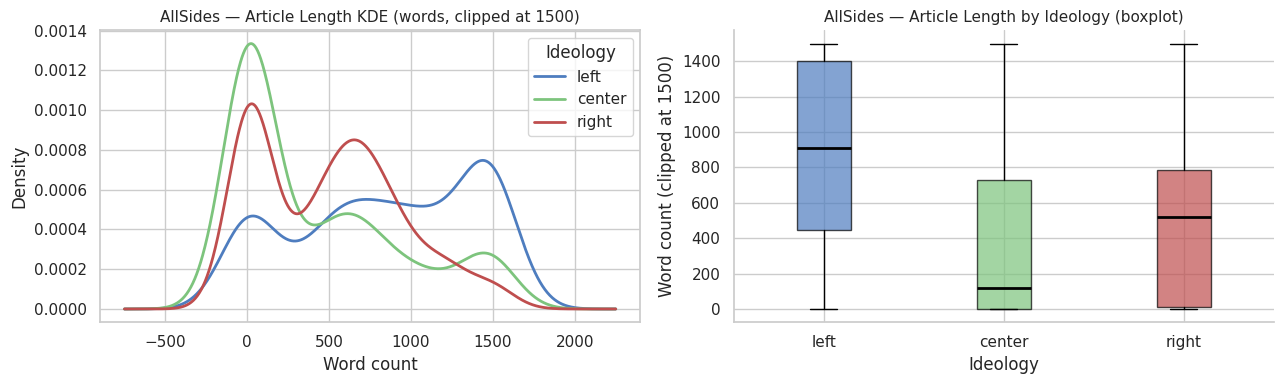

✅ Length-by-ideology plots saved


In [43]:
# ── Figure 2: Word-length distribution by ideology ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# KDE per ideology
ax = axes[0]
for label in label_order:
    subset = allsides_df[allsides_df["ideology"] == label]["word_count"].clip(upper=1500)
    if len(subset) > 0:
        subset.plot.kde(ax=ax, label=label, color=label_colors[label], lw=2)
ax.set_title("AllSides — Article Length KDE (words, clipped at 1500)", fontsize=11)
ax.set_xlabel("Word count")
ax.set_ylabel("Density")
ax.legend(title="Ideology")

# Box plot
ax2 = axes[1]
data_by_label = [allsides_df[allsides_df["ideology"] == l]["word_count"].clip(upper=1500).values
                 for l in label_order]
bp = ax2.boxplot(data_by_label, labels=label_order, patch_artist=True, notch=False,
                 medianprops=dict(color="black", lw=2))
for patch, label in zip(bp["boxes"], label_order):
    patch.set_facecolor(label_colors[label])
    patch.set_alpha(0.7)
ax2.set_title("AllSides — Article Length by Ideology (boxplot)", fontsize=11)
ax2.set_xlabel("Ideology")
ax2.set_ylabel("Word count (clipped at 1500)")
sns.despine(ax=ax2)

plt.tight_layout()
plt.savefig("outputs/allsides_length_by_ideology.png", dpi=150)
shutil.copy("outputs/allsides_length_by_ideology.png",
            f"{DRIVE_DIR}/allsides_length_by_ideology.png")
plt.show()
print("✅ Length-by-ideology plots saved")

---
## 4. Summary Checks & Quick Health Report

In [57]:
# ── Print a consolidated health report ──────────────────────────────────────
print("=" * 60)
print("WEEK 1 HEALTH REPORT")
print("=" * 60)

print("\n── WNC ──")
print(f"  Training pairs       : {len(wnc_train_df):,}")
for split_name, split_file in [("train", "biased.word.train"), ("dev", "biased.word.dev"), ("test", "biased.word.test")]:
    path = f"/content/wnc_data/{split_file}"  # adjust folder path if needed
    if os.path.exists(path):
        n = pd.read_csv(path, sep="\t", header=None, on_bad_lines="skip").shape[0]
        print(f"  {split_name} split           : {n:,}")
print(f"  Biased avg len (wds) : {wnc_train_df['biased_len'].mean():.1f}")
print(f"  Neutral avg len (wds): {wnc_train_df['neutral_len'].mean():.1f}")
null_biased  = wnc_train_df["biased"].isnull().sum()
null_neutral = wnc_train_df["neutral"].isnull().sum()
print(f"  Null biased sentences: {null_biased}")
print(f"  Null neutral sentences: {null_neutral}")
wnc_ok = (null_biased == 0) and (null_neutral == 0)
print(f"  Status: {'✅ CLEAN' if wnc_ok else '⚠️  NEEDS CLEANING'}")

print("\n── AllSides ──")
print(f"  Total articles       : {len(allsides_df):,}")
for label in label_order:
    n = (allsides_df["ideology"] == label).sum()
    print(f"  {label.capitalize():8s} articles   : {n:,}")
null_text  = allsides_df[text_col].isnull().sum()
null_label = allsides_df["ideology"].isnull().sum()
print(f"  Null text            : {null_text}")
print(f"  Null label           : {null_label}")
allsides_ok = (null_text == 0) and (null_label == 0)
print(f"  Status: {'✅ CLEAN' if allsides_ok else '⚠️  NEEDS CLEANING — handle nulls in Week 2'}")

print("=" * 60)
print("Ready for Week 2 preprocessing.") if (wnc_ok and allsides_ok) else print(
    "Address the warnings above before Week 2.")

WEEK 1 HEALTH REPORT

── WNC ──
  Training pairs       : 53,803
  Biased avg len (wds) : 26.4
  Neutral avg len (wds): 26.1
  Null biased sentences: 0
  Null neutral sentences: 0
  Status: ✅ CLEAN

── AllSides ──
  Total articles       : 987
  Left     articles   : 328
  Center   articles   : 328
  Right    articles   : 331
  Null text            : 0
  Null label           : 0
  Status: ✅ CLEAN
Ready for Week 2 preprocessing.


In [58]:
# ── Print sample pairs from WNC ──────────────────────────────────────────────
print("Sample WNC pairs (biased → neutral):")
print("-" * 60)
for _, row in wnc_train_df.sample(3, random_state=SEED).iterrows():
    print(f"  BIASED : {row['biased']}")
    print(f"  NEUTRAL: {row['neutral']}")
    print()

Sample WNC pairs (biased → neutral):
------------------------------------------------------------
  BIASED : the term "american" is frequently misused to mean a citizen of the united states of america, despite the fact that anyone who lives in the americas is technically an "american".
  NEUTRAL: the term "american" is frequently used to mean a citizen of the united states of america, despite the fact that anyone who lives in the americas is technically an "american".

  BIASED : lanark blue is a full-flavoured cheese produced in lanarkshire, scotland.
  NEUTRAL: lanark blue is a sheep milk cheese produced in lanarkshire, scotland.

  BIASED : this suggests that the version of history portrayed in "the book" book is not entirely accurate (which again supports the thesis that it is a fake: the inherent unreliability of all written sources is one of orwell's points).
  NEUTRAL: this suggests that the version of history portrayed in "the book" is not entirely accurate (which again support

In [59]:
# ── Print sample articles from AllSides (one per label) ──────────────────────
print("Sample AllSides snippets (first 300 chars per article):")
print("-" * 60)
for label in label_order:
    row = allsides_df[allsides_df["ideology"] == label].sample(1, random_state=SEED).iloc[0]
    print(f"  [{label.upper()}] {str(row[text_col])[:300]} ...")
    print()

Sample AllSides snippets (first 300 chars per article):
------------------------------------------------------------
  [LEFT] Fox & Friends Opens Show With Unintelligible Word Salad Explaining Why New Trump Charges Are Unfair
Colby HallJul 28th, 2023, 10:11 am
  Twitter share button
Want to avoid video ads? Subscribe to
Fox & Friends viewers who wanted to know why the recent federal charges against former President Donald  ...

  [CENTER] According to a new survey, 25% of people have not taken a vacation because of too much email when ... [+]
Memorial Day unofficially marks the beginning of summer for Americans, which is also the most popular time of year to take vacations and long weekends. Unfortunately, endless work messages and o ...

  [RIGHT] NRPLUS
POLITICS & POLICY
Do We Realize What the Violence of Abortion Has Done to Us?
A woman uses a megaphone as pro-life demonstrators take part in the annual March for Life in Washington, D.C., January 20, 2023. (Evelyn Hockstein/Reuters)


---
## 5. Push to GitHub

Run this cell at the end of every session.

In [64]:
import os, shutil

os.makedirs(f"/content/{REPO_NAME}/notebooks", exist_ok=True)
shutil.copy(
    "/content/drive/MyDrive/Colab Notebooks/week1_exploration.ipynb",
    f"/content/{REPO_NAME}/notebooks/week1_exploration.ipynb"
)
print("✅ Notebook copied into repo/notebooks/")

✅ Notebook copied into repo/notebooks/


In [76]:
!git reset HEAD~1


In [77]:
!git config user.email "kavyat1102@gmail.com"
!git config user.name "Kavya"
!git add -A
!git commit -m "week1 exploration complete"
!git push --force
print("✅ Pushed to GitHub")

[main 0df75a0] week1 exploration complete
 5 files changed, 2 insertions(+)
 create mode 100644 notebooks/week1_exploration.ipynb
 create mode 100644 outputs/allsides_label_distribution.png
 create mode 100644 outputs/allsides_length_by_ideology.png
 create mode 100644 outputs/wnc_length_distribution.png
 create mode 100644 paper/.gitkeep
Enumerating objects: 10, done.
Counting objects: 100% (10/10), done.
Delta compression using up to 2 threads
Compressing objects: 100% (8/8), done.
Writing objects: 100% (8/8), 447.39 KiB | 6.88 MiB/s, done.
Total 8 (delta 0), reused 0 (delta 0), pack-reused 0
remote: error: GH013: Repository rule violations found for refs/heads/main.
remote: 
remote: - GITHUB PUSH PROTECTION
remote:   —————————————————————————————————————————
remote:     Resolve the following violations before pushing again
remote: 
remote:     - Push cannot contain secrets
remote: 
remote:     
remote:      (?) Learn how to resolve a blocked push
remote:      https://docs.github.com